# Linear Classification on the MNIST Dataset

In this notebook we will see a bunch of algorithms working applied to the MNIST dataset.

The dataset contains $70,000$ single channel images ( $1 \times 28 \times 28$ pixels) representing handwritten digits from $0$ to $9$. The dataset is divided into $60,000$ training images and $10,000$ test images.

In this example we will play with a subset of the dataset, containing $1800$ images downscaled to an $8 \times 8$ resolution, which can easily be downloaded using Scikit-Learn.

![alt_text](https://datasets.activeloop.ai/wp-content/uploads/2019/12/MNIST-handwritten-digits-dataset-visualized-by-Activeloop.webp)

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier, LogisticRegression
from sklearn.metrics import accuracy_score

import matplotlib.pyplot as plt
%matplotlib inline

## Obtaining the Dataset

We will use the [`load_digits`](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.load_digits.html) function from the `sklearn.datasets` module to load the dataset.

In [2]:
mnist = load_digits()
mnist.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [3]:
X = mnist["images"]
y = mnist["target"]
X.shape, y.shape  # X, y

((1797, 8, 8), (1797,))

In [4]:
# show min and max value of images
X.min(), X.max()

(np.float64(0.0), np.float64(16.0))

In [5]:
# show the first image with its label
X[0], y[0]

(array([[ 0.,  0.,  5., 13.,  9.,  1.,  0.,  0.],
        [ 0.,  0., 13., 15., 10., 15.,  5.,  0.],
        [ 0.,  3., 15.,  2.,  0., 11.,  8.,  0.],
        [ 0.,  4., 12.,  0.,  0.,  8.,  8.,  0.],
        [ 0.,  5.,  8.,  0.,  0.,  9.,  8.,  0.],
        [ 0.,  4., 11.,  0.,  1., 12.,  7.,  0.],
        [ 0.,  2., 14.,  5., 10., 12.,  0.,  0.],
        [ 0.,  0.,  6., 13., 10.,  0.,  0.,  0.]]),
 np.int64(0))

<Figure size 640x480 with 0 Axes>

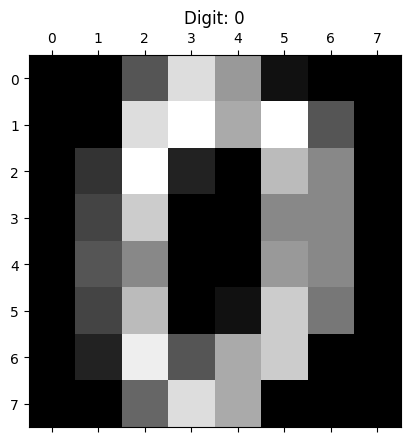

In [6]:
plt.gray()
plt.matshow(X[0])
plt.title(f"Digit: {y[0]}")
plt.show()

# Visualizing the Data

Since we have $8 \times 8 = 64$ features, we cannot use all of them to see the data distribution, also because the data is not represented by a bunch of feature vectors, but each data point is an image, therefore it is a matrix. So, in this case, we first **flatten** the images in order to get a feature vector, than we will perform a **PCA** to extract the first two principal components, which will be used to have a plot.

In [7]:
# Standardize features by removing the mean and scaling to unit variance.
# The standard score of a sample x is calculated as:
# z = (x - u) / s
# where u is the mean of the training samples or zero if with_mean=False, and s is the standard deviation of the training samples.

X_flat = X.reshape(-1, 8*8)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)
X_scaled.shape

(1797, 64)

In [8]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
X_pca

array([[-1.91421366, -0.95450157],
       [-0.58898033,  0.9246358 ],
       [-1.30203906, -0.31718883],
       ...,
       [-1.02259599, -0.14791087],
       [-1.07605522, -0.38090625],
       [ 1.25770233, -2.22759088]])

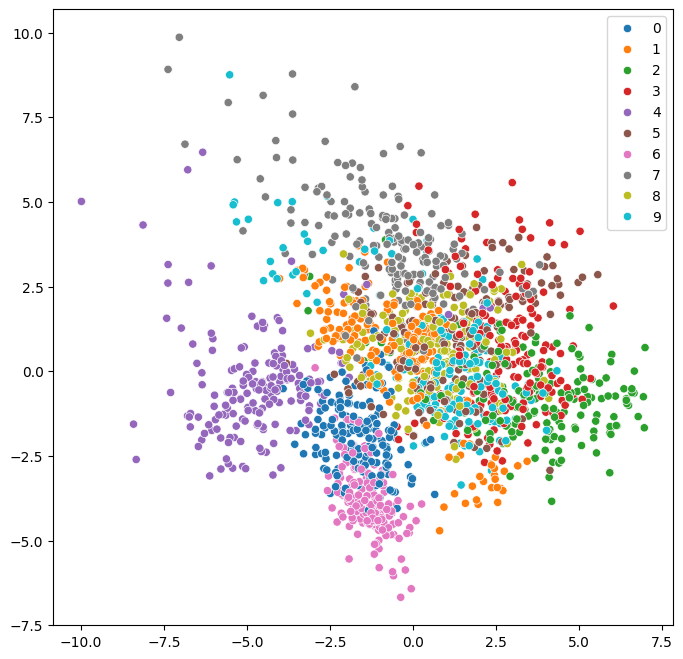

In [9]:
# show the data with hue as the target and legend
plt.figure(figsize=(8, 8))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=y, palette="tab10")
plt.show()

## Logistic Regression on the PCA Features

In [10]:
# make a logistic regression on X_pca and show the decision boundaries
X_train, X_test, y_train, y_test = train_test_split(X_pca, y, test_size=0.2, random_state=42)

log_reg = LogisticRegression(C=2)
log_reg.fit(X_train, y_train)

y_pred = log_reg.predict(X_test)
accuracy_score(y_test, y_pred)

0.5444444444444444

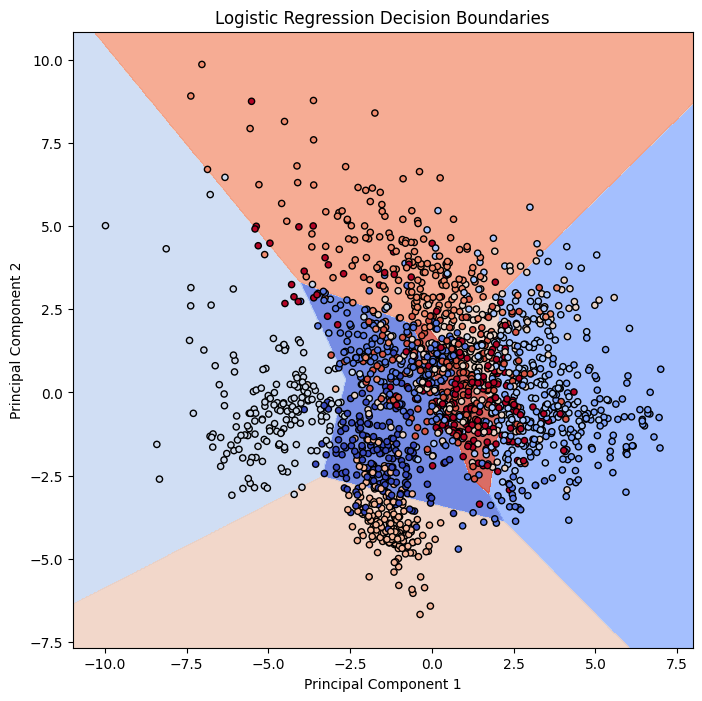

In [11]:
# Train the logistic regression model
log_reg.fit(X_pca, y)

# Define the meshgrid for the feature space
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                     np.arange(y_min, y_max, 0.02))

# Make predictions on the meshgrid points
Z = log_reg.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot the data points
plt.figure(figsize=(8, 8))

# Plot the decision boundaries
plt.contourf(xx, yy, Z, alpha=0.8, cmap=plt.cm.coolwarm)
plt.scatter(x=X_pca[:, 0], y=X_pca[:, 1], c=y, edgecolors="k", s=20, cmap=plt.cm.coolwarm)

# Set plot limits and labels
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('Logistic Regression Decision Boundaries')

# Show the plot
plt.show()


In [12]:
xx.shape, yy.shape

((927, 949), (927, 949))

In [13]:
np.unique(Z)

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

## Split the Data
Once we have seen our data, we split it into training and test set.

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_flat, y, stratify=y, test_size=0.2, random_state=42)

## Fitting a Linear Classifier

Scikit-Learn's `SGDClassifier` is a wrapper around linear models for classification (SVM, logistic regression, etc.) that implements a stochastic gradient descent algorithm.

In this example we train (again) a logistic regression model on the training data, this time using all the features.
The loss function to minimize is the cross-entropy loss defined as:

$$
- \frac{1}{N} \sum_{i=1}^{N} \sum_{c=1}^{C} y_{ic} \log(\hat{y}_{ic})
$$

where $N$ is the number of samples, $y_i$ is the true label of the $i$-th sample and $\hat{y}_i$ is the predicted probability that the $i$-th sample belongs to the positive class.

$\hat{y}_{ic}$ is computed as:

$$
\hat{y}_{ic} = \frac{\exp(\mathbf{w}_c^T \mathbf{x}_i)}{\sum_{c'=1}^{C} \exp(\mathbf{w}_{c'}^T \mathbf{x}_i)}
$$

where $\mathbf{w}_c$ is the weight vector for class $c$ and $\mathbf{x}_i$ is the feature vector of the $i$-th sample.

In [15]:
model = SGDClassifier(loss='log_loss',
                      penalty='l1',
                      random_state=42)

model.fit(X_train, y_train)

print(f'W has shape {model.coef_.shape}')
print(f"Accuracy: {model.score(X_test, y_test)}")

W has shape (10, 64)
Accuracy: 0.9555555555555556


<Figure size 640x480 with 0 Axes>

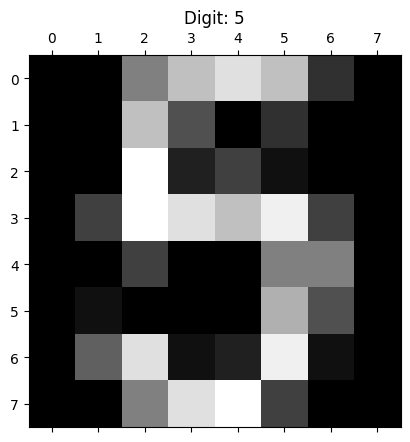

In [16]:
plt.gray()
plt.matshow(X_test[0].reshape((8, 8)))
plt.title(f"Digit: {y_test[0]}")
plt.show()

In [17]:
model.predict(X_test[[0]])

array([5])

## Fitting Other Classifiers

We will also fit a Support Vector Machine and a Random Forest classifier to the data.

In [18]:
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

# compare other basic classifiers on the same data
models = []

# K-NN
models.append(('KNN with 5 neighbors', KNeighborsClassifier(n_neighbors=5)))

# linear classifier with cross-entropy loss (logistic regression)
models.append(('SGD with cross-entropy loss', SGDClassifier(loss='log_loss', penalty='l2', alpha=0.001)))

# SVM
models.append(('SVM', SVC(C=10, random_state=42)))

print('Accuracy on test set\n')
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    print(f'{name:<30}: {accuracy:.4f}')

Accuracy on test set

KNN with 5 neighbors          : 0.9833
SGD with cross-entropy loss   : 0.9500
SVM                           : 0.9944


## Cross-Validation

In [19]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

for name, model in models:
    scores = cross_val_score(model, X_flat, y, cv=kf)
    print(f'{name:<30}: {scores.mean():.4f} (+/- {scores.std():.4f})')

KNN with 5 neighbors          : 0.9861 (+/- 0.0109)
SGD with cross-entropy loss   : 0.9571 (+/- 0.0114)
SVM                           : 0.9911 (+/- 0.0062)
